In [ ]:
Detecção de Pneumonia por exames de raio-x

Podemos baixar o dataset de duas formas.
- Usando o kaggle hub, mas isso exige uma api key cadastrada no usuario e upload no collab.
- Baixar o dataset e fazer o upload aqui.
Caso opte pelo download: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-
pneumonia


In [2]:
# Instalar biblioteca do Kaggle
!pip install -q kaggle

# Fazer upload do kaggle.json com as credenciais
from google.colab import files
print("Faça o upload do seu kaggle.json:")
uploaded = files.upload()

# Configurar credenciais
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Credenciais configuradas com sucesso!")

Faça o upload do seu kaggle.json:


Saving kaggle.json to kaggle.json
Credenciais configuradas com sucesso!


In [3]:
!kaggle datasets download -d "paultimothymooney/chest-xray-pneumonia" \
    --unzip -p /content/dataset

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:19<00:00, 124MB/s] 



In [ ]:
Importação de bibliotecas

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
import random
import numpy as np

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
Aqui não carregamos o dataset de validação por ser muito pequeno. Apenas 16 imagens.

In [28]:
# Caminho base (ajuste conforme seu ambiente)
BASE_DIR = "/content/dataset/chest_xray"

# Caminhos principais
train_dir = os.path.join(BASE_DIR, "train")
test_dir = os.path.join(BASE_DIR, "test")

def load_dataset(path):
    imagens = []
    labels = []

    classes = ["NORMAL", "PNEUMONIA"]

    for label, classe in enumerate(classes):
        classe_path = os.path.join(path, classe)
        for arquivo in os.listdir(classe_path):
            caminho_imagem = os.path.join(classe_path, arquivo)

            imagens.append(caminho_imagem)
            labels.append(label)

    return imagens, labels

images_train, labels_train = load_dataset(train_dir)
images_test, labels_test = load_dataset(test_dir)


print("Train:", len(images_train))
print("Test:", len(images_test))

Train: 5216
Test: 624
Validação: 16


Train (NORMAL): 1341 PNEUMONIA:  3875
Test (NORMAL): 234 PNEUMONIA:  390
Validação (NORMAL): 8 PNEUMONIA:  8


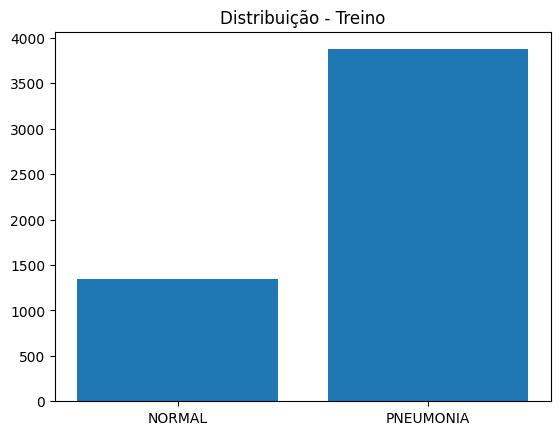

In [30]:
def class_count(labels):
    normal = sum(1 for l in labels if l == 0)
    pneumonia = sum(1 for l in labels if l == 1)
    return normal, pneumonia

train_normal, train_pneumonia = class_count(labels_train)
test_normal, test_pneumonia = class_count(labels_test)

print(f"Train (NORMAL): {train_normal} PNEUMONIA:  {train_pneumonia}")
print(f"Test (NORMAL): {test_normal} PNEUMONIA:  {test_pneumonia}")

labels_names = ['NORMAL', 'PNEUMONIA']

train_counts = [train_normal, train_pneumonia]

plt.bar(labels_names, train_counts)
plt.title("Distribuição - Treino")
plt.show()

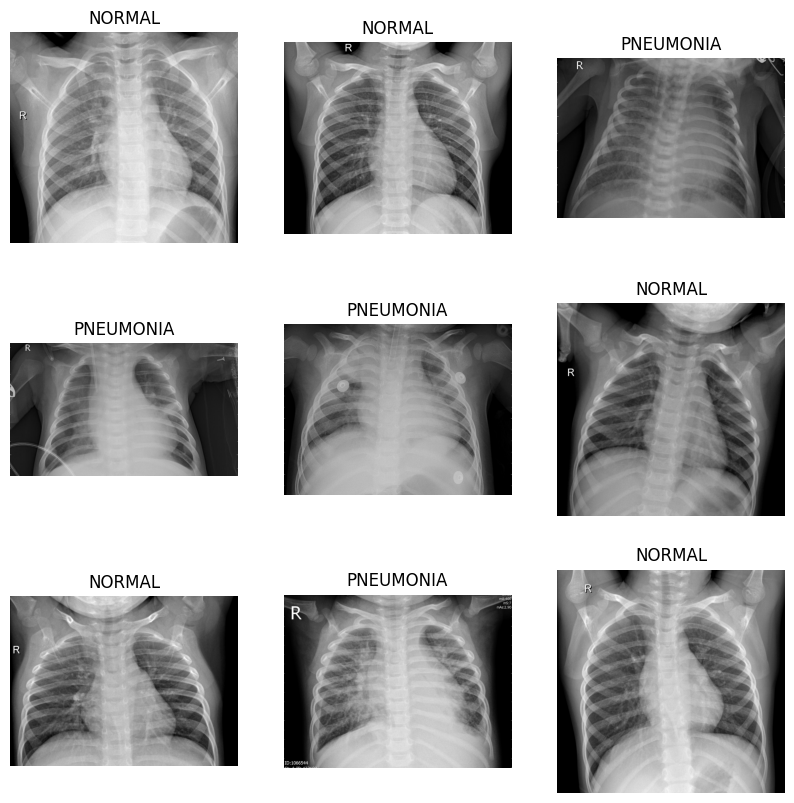

In [32]:
plt.figure(figsize=(10, 10))

for i in range(9):

    idx = random.randint(0, len(images_train)-1)

    img_path = images_train[idx]
    label = labels_train[idx]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title("PNEUMONIA" if label == 1 else "NORMAL")
    plt.axis('off')

plt.show()

In [33]:
sizes = []

for path in images_train[:100]:  # amostra
    img = cv2.imread(path)
    sizes.append(img.shape)

print("Tamanhos:", sizes[:5])

Exemplos de tamanhos: [(1638, 1724, 3), (1313, 1654, 3), (1337, 1508, 3), (1603, 2016, 3), (1090, 1522, 3)]


In [36]:
# Configurações para pré-processamento
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalização
    validation_split=0.2,    # separa 20% dos dados para validação
    rotation_range=10,       # pequena rotação (segura pra medicina)
    zoom_range=0.1,          # zoom leve
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [39]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,  # aqui usamos o mesmo diretório de treino, pois fizemos split e vamos ignorar a pasta val pois ela está muito pequena!
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Treinamento

In [40]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Conv 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Conv 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Conv 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten
model.add(layers.Flatten())

# Dense + Dropout
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))  # reduz overfitting

# Output
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [47]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=7
)

Epoch 1/7
 36/131 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - accuracy: 0.9374 - auc: 0.9786 - loss: 0.1527 - precision: 0.9522 - recall: 0.9663

KeyboardInterrupt: 

In [43]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Teste accuracy: {test_acc * 100:.2f}% Teste loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.8237 - loss: 0.4779
Teste accuracy: 82.37% Teste loss: 0.4779
